# Testing confidence intervals
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

### (1) Definition of random number generation and limits

In [2]:
# Parameters of the Poisson distribution

mean = 10
sigma = np.sqrt(mean)

# Considered limits

limlow = np.array([mean-sigma, mean-2*sigma,mean-3*sigma,mean-4*sigma,mean-5*sigma])
limhig = np.array([mean+sigma, mean+2*sigma,mean+3*sigma,mean+4*sigma,mean+5*sigma])

# Number of generations

Nmc = 100000000


### (2) Generate multiple numbers

In [3]:
rvec = np.random.poisson(mean,size=(Nmc))

### (3)  Count limit probability

In [4]:
print("\nLower limit probability:")

for ll in limlow :
    nl = np.sum(rvec < ll)
    p = nl/Nmc
    ep = np.sqrt(p*(1-p)/Nmc)
    print (f" P ( x < {ll:+.3f}) = {p:.4g} +/- {ep:.2g}")
    
print("\nUpper limit probability:")

for ul in limhig :
    nl = np.sum(rvec > ul)
    p = nl/Nmc
    ep = np.sqrt(p*(1-p)/Nmc)
    print (f" P ( x > {ul:.3f}) = {p:.4g} +/- {ep:.2g}")
    


Lower limit probability:
 P ( x < +6.838) = 0.1301 +/- 3.4e-05
 P ( x < +3.675) = 0.01033 +/- 1e-05
 P ( x < +0.513) = 4.624e-05 +/- 6.8e-07
 P ( x < -2.649) = 0 +/- 0
 P ( x < -5.811) = 0 +/- 0

Upper limit probability:
 P ( x > 13.162) = 0.1356 +/- 3.4e-05
 P ( x > 16.325) = 0.02705 +/- 1.6e-05
 P ( x > 19.487) = 0.003454 +/- 5.9e-06
 P ( x > 22.649) = 0.0002962 +/- 1.7e-06
 P ( x > 25.811) = 1.839e-05 +/- 4.3e-07


### (4) Plot distribution histogram

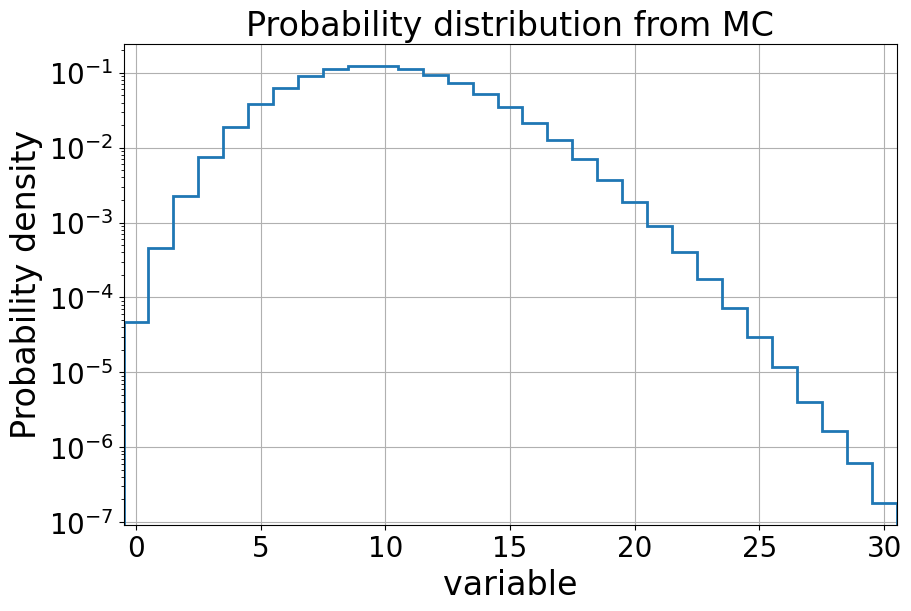

In [5]:
# Range for result histogram

Xmax=30.5
Nbin = 31

# Plot histogram

plt.figure(figsize=(9, 6),layout='constrained')

plt.hist(rvec,bins=Nbin, range=[-0.5,Xmax], density=True, log=True, histtype='step',linewidth=2)

plt.title("Probability distribution from MC",size=24)
plt.xlabel('variable',size=24)
plt.ylabel('Probability density',size=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim([-0.5,Xmax])
plt.grid(which='major', axis='both')

fname = '06_interval_2.png'
plt.savefig(fname)

plt.show()